# Atlas-v1: head-family inventory at Pythia-410M

Exploratory map of attention-head families across the 40-checkpoint §H2-1 schedule.
Five new families (previous-token, duplicate-token, positional-offset, BOS-attention,
delimiter) plus the three locked §H1-C motifs (induction, successor, S-inhibition).

**Atlas thresholds (calibrated at step143000, post-smoke):**

| Family | Threshold | Source |
|---|---|---|
| induction | 0.30 | `src.locked_thresholds.INDUCTION_QK` |
| successor | 0.13496 | `src.locked_thresholds.SUCCESSOR_LIFT` |
| s_inhibition | 0.0372 | `src.locked_thresholds.S_INHIBITION_DELTA` |
| previous_token | 0.20 | `src.atlas.thresholds.PREVIOUS_TOKEN` |
| duplicate_token | 0.20 | `src.atlas.thresholds.DUPLICATE_TOKEN` |
| positional_offset | 0.15 | `src.atlas.thresholds.POSITIONAL_OFFSET` |
| bos_attention | 0.50 | `src.atlas.thresholds.BOS_ATTENTION` |
| delimiter | 0.40 | `src.atlas.thresholds.DELIMITER` |


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.atlas.thresholds import ALL_ATLAS_THRESHOLDS
from src.locked_thresholds import INDUCTION_QK, SUCCESSOR_LIFT, S_INHIBITION_DELTA

FIG_DIR = REPO / "notebooks" / "figures" / "atlas_v1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load atlas-v1 sweep
atlas = pd.read_parquet(REPO / "data" / "atlas" / "atlas_v1_410m_sweep.parquet")
print(f"atlas: {len(atlas):,} rows, motifs={sorted(atlas['motif'].unique())}, steps={atlas['step'].nunique()}")

# Load locked-motif sweeps; keep 410m only
locked_parts = []
for motif, fname in [
    ("induction",    "phase2_induction_sweep.parquet"),
    ("successor",    "phase2_successor_sweep.parquet"),
    ("s_inhibition", "phase2_s_inhibition_sweep.parquet"),
]:
    p = REPO / "data" / "exploration" / fname
    df = pd.read_parquet(p)
    df = df[df["size"] == "410m"].copy()
    df["motif"] = motif
    locked_parts.append(df[["size", "step", "layer", "head", "motif", "score"]])
locked = pd.concat(locked_parts, ignore_index=True)
print(f"locked: {len(locked):,} rows, motifs={sorted(locked['motif'].unique())}, steps={locked['step'].nunique()}")

# Combined registry of thresholds for every family
THRESHOLDS = {
    "induction":         (INDUCTION_QK.value,         INDUCTION_QK.comparator),
    "successor":         (SUCCESSOR_LIFT.value,       SUCCESSOR_LIFT.comparator),
    "s_inhibition":      (S_INHIBITION_DELTA.value,   S_INHIBITION_DELTA.comparator),
    "previous_token":    (0.20, "ge"),
    "duplicate_token":   (0.20, "ge"),
    "positional_offset": (0.15, "ge"),
    "bos_attention":     (0.50, "ge"),
    "delimiter":         (0.40, "ge"),
}

MOTIF_ORDER = [
    "induction", "successor", "s_inhibition",
    "previous_token", "duplicate_token", "positional_offset",
    "bos_attention", "delimiter",
]
MOTIF_COLORS = {
    "induction":         "#1f77b4",
    "successor":         "#ff7f0e",
    "s_inhibition":      "#2ca02c",
    "previous_token":    "#d62728",
    "duplicate_token":   "#9467bd",
    "positional_offset": "#8c564b",
    "bos_attention":     "#e377c2",
    "delimiter":         "#17becf",
}


def pass_count_traj(df: pd.DataFrame, motif: str) -> pd.Series:
    """Return Series index=step, value=count of (layer, head) passing the motif threshold."""
    thr_val, op = THRESHOLDS[motif]
    sub = df[df["motif"] == motif]
    if op == "gt":
        per = sub.groupby("step").apply(lambda g: int((g["score"] > thr_val).sum()), include_groups=False)
    else:
        per = sub.groupby("step").apply(lambda g: int((g["score"] >= thr_val).sum()), include_groups=False)
    return per.sort_index()


combined = pd.concat([locked, atlas[["size", "step", "layer", "head", "motif", "score"]]], ignore_index=True)
print(f"combined: {len(combined):,} rows across {len(MOTIF_ORDER)} motifs")


atlas: 76,800 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'positional_offset', 'previous_token'], steps=40
locked: 46,080 rows, motifs=['induction', 's_inhibition', 'successor'], steps=40
combined: 122,880 rows across 8 motifs


## §1. Headline — pass-count trajectories for all 8 families at Pythia-410M

Each curve = number of (layer, head) pairs whose detector score clears the family-specific
threshold at that training step. Two patterns to look for: monotonic emergence vs. transient
over-emergence (rise then collapse).


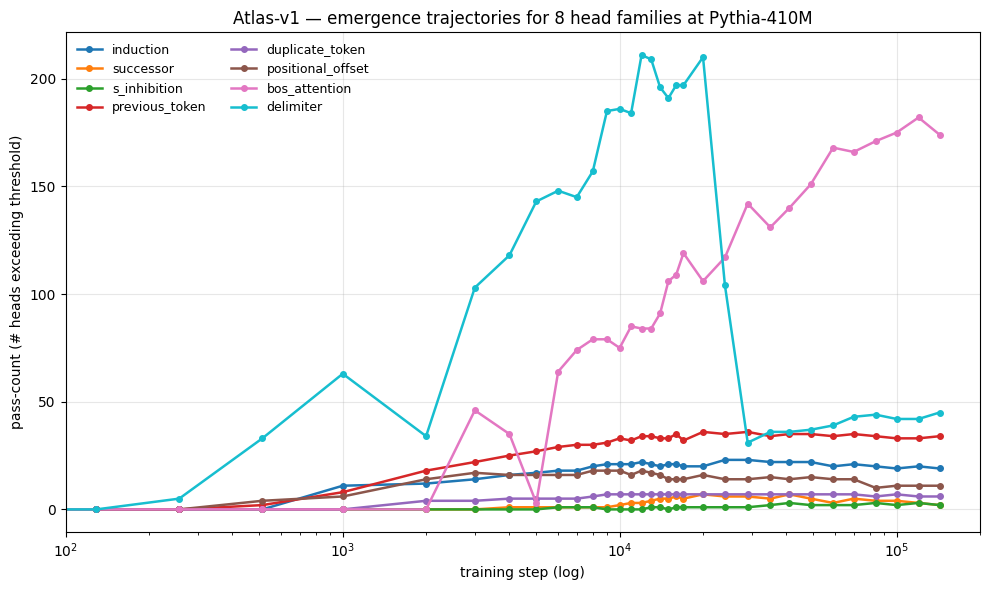

saved notebooks/figures/atlas_v1/F1_atlas_headline.png


In [2]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for motif in MOTIF_ORDER:
    traj = pass_count_traj(combined, motif)
    ax.plot(
        traj.index.values + 1,  # +1 to allow step=0 on log scale
        traj.values,
        "o-",
        color=MOTIF_COLORS[motif],
        linewidth=1.8,
        markersize=4,
        label=motif,
    )
ax.set_xscale("log")
ax.set_xlim(100, 200_000)
ax.set_xlabel("training step (log)")
ax.set_ylabel("pass-count (# heads exceeding threshold)")
ax.set_title("Atlas-v1 — emergence trajectories for 8 head families at Pythia-410M")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncol=2, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "F1_atlas_headline.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'F1_atlas_headline.png').relative_to(REPO)}")


## §2. Per-family pass-count panels

Same data, 8 panels — each family on its own y-axis so trajectories with small absolute
counts (duplicate_token, positional_offset) aren't squashed by bos_attention.


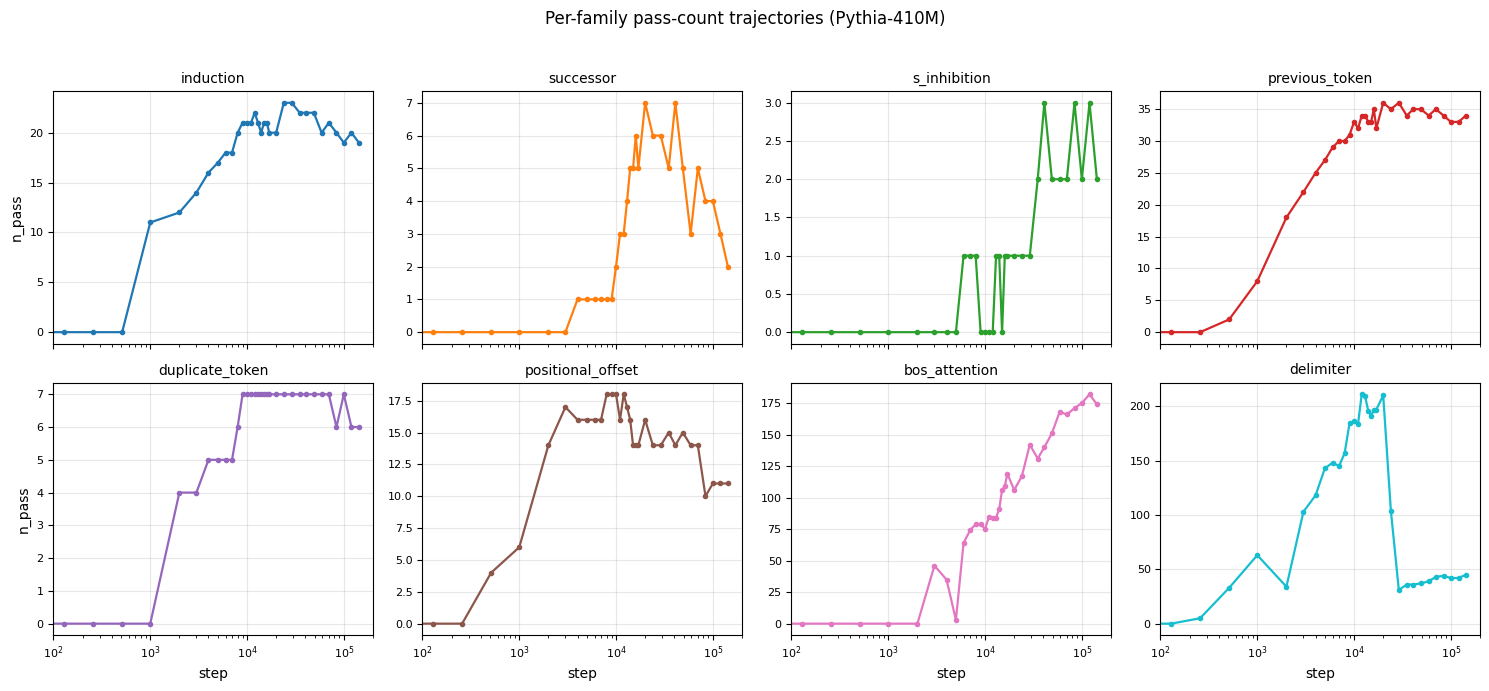

saved notebooks/figures/atlas_v1/F2_per_family_panels.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True)
for ax, motif in zip(axes.flatten(), MOTIF_ORDER):
    traj = pass_count_traj(combined, motif)
    ax.plot(
        traj.index.values + 1,
        traj.values,
        "o-",
        color=MOTIF_COLORS[motif],
        linewidth=1.6,
        markersize=3,
    )
    ax.set_xscale("log")
    ax.set_xlim(100, 200_000)
    ax.set_title(motif, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
for ax in axes[1, :]:
    ax.set_xlabel("step")
for ax in axes[:, 0]:
    ax.set_ylabel("n_pass")
fig.suptitle("Per-family pass-count trajectories (Pythia-410M)", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig(FIG_DIR / "F2_per_family_panels.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'F2_per_family_panels.png').relative_to(REPO)}")


## §3. Per-(layer, head) emergence heatmap, 5 atlas families

Each row = one head index; each column = one training step. Color = whether the head passes
its family's threshold at that step. Lets you see WHICH heads emerge WHEN per family.


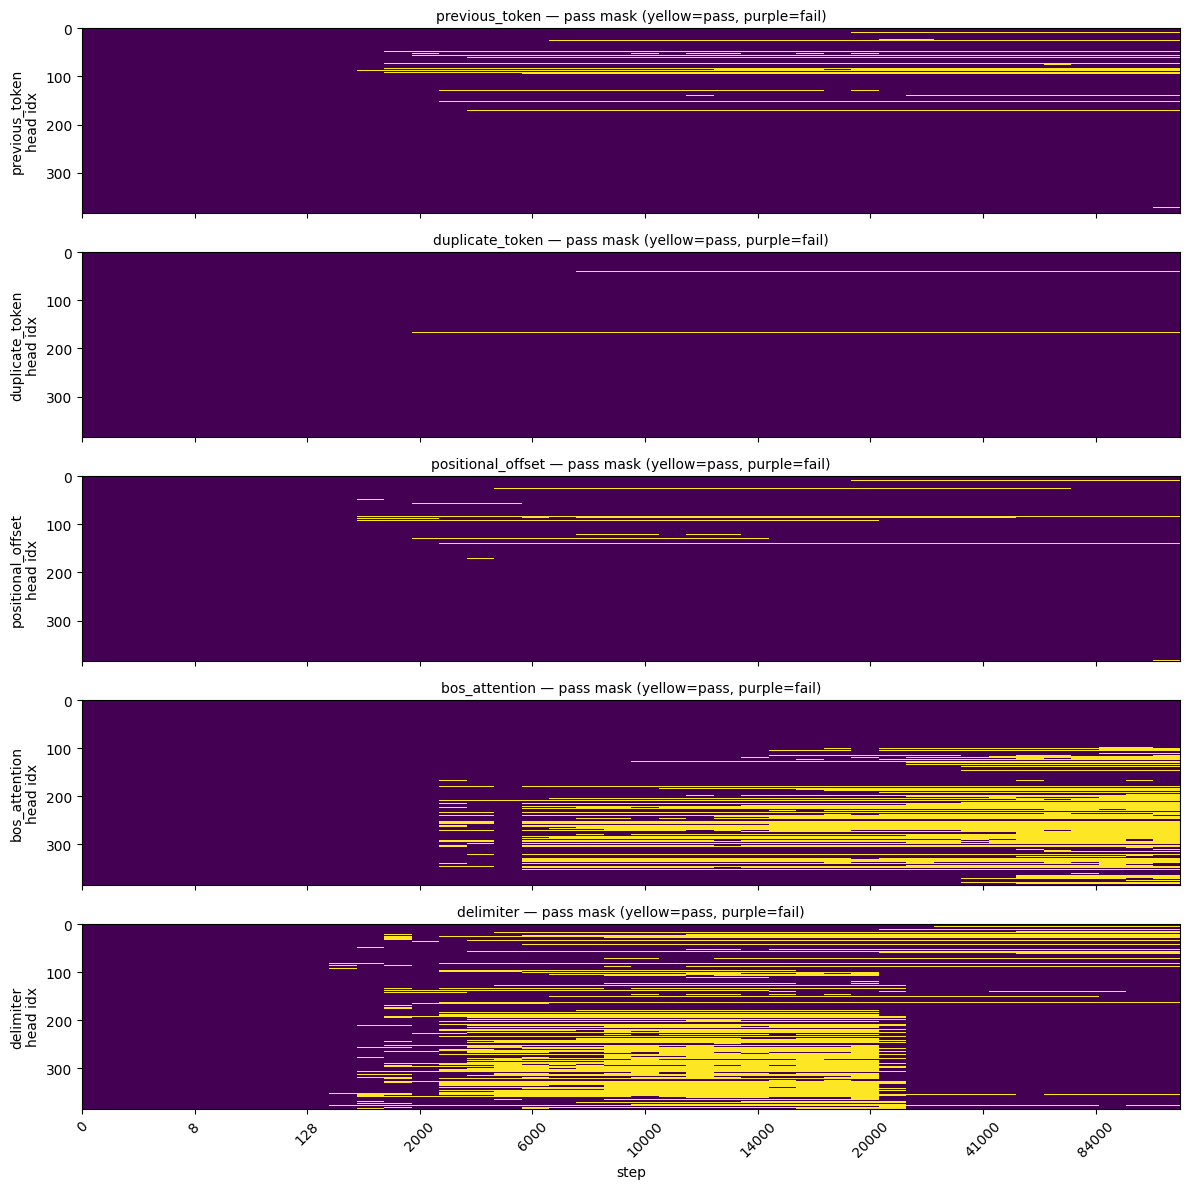

saved notebooks/figures/atlas_v1/F3_emergence_heatmaps.png


In [4]:
atlas_motifs = ["previous_token", "duplicate_token", "positional_offset", "bos_attention", "delimiter"]
fig, axes = plt.subplots(len(atlas_motifs), 1, figsize=(12, 12), sharex=True)

steps = sorted(atlas["step"].unique())
step_to_col = {s: i for i, s in enumerate(steps)}

for ax, motif in zip(axes, atlas_motifs):
    thr_val, op = THRESHOLDS[motif]
    sub = atlas[atlas["motif"] == motif].copy()
    # 384 heads = 24 layers x 16 heads
    sub["head_idx"] = sub["layer"] * 16 + sub["head"]
    if op == "gt":
        sub["passes"] = sub["score"] > thr_val
    else:
        sub["passes"] = sub["score"] >= thr_val
    M = sub.pivot_table(index="head_idx", columns="step", values="passes", fill_value=False).astype(int)
    M = M.reindex(columns=steps, fill_value=0)
    im = ax.imshow(
        M.values, aspect="auto", cmap="viridis", interpolation="nearest",
        extent=[0, len(steps) - 1, 384, 0],
    )
    ax.set_ylabel(f"{motif}\nhead idx")
    ax.set_title(f"{motif} — pass mask (yellow=pass, purple=fail)", fontsize=10)

axes[-1].set_xticks(range(0, len(steps), 4))
axes[-1].set_xticklabels([str(steps[i]) for i in range(0, len(steps), 4)], rotation=45)
axes[-1].set_xlabel("step")
plt.tight_layout()
plt.savefig(FIG_DIR / "F3_emergence_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'F3_emergence_heatmaps.png').relative_to(REPO)}")


## §4. Notable trajectories

Two patterns stand out in the headline data:

1. **Delimiter transient**: peaks at ~211 heads around step 12000, collapses to ~30-45 by
   convergence — most heads briefly attend to punctuation early in training, then specialize
   away.
2. **BOS-attention monotonic late climb**: still growing at step 120000, consistent with
   "BOS sink" being a stable default — more heads adopt it as training continues.


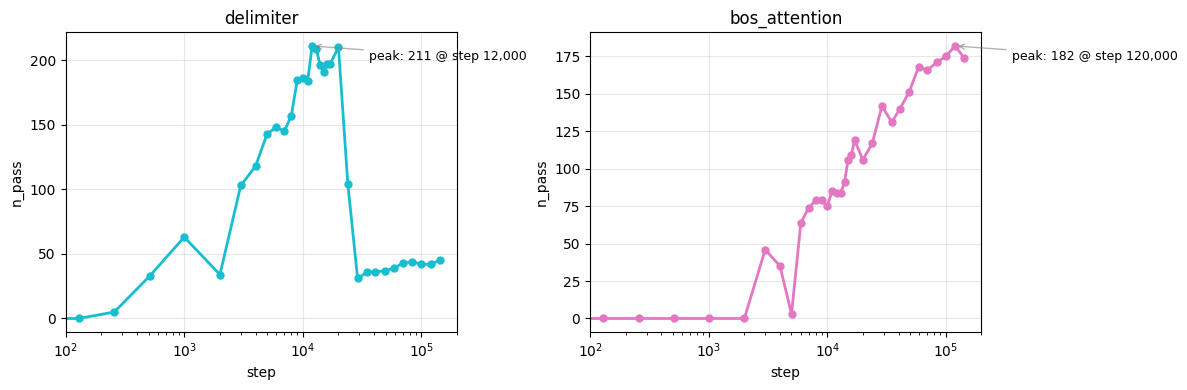

saved notebooks/figures/atlas_v1/F4_notable_trajectories.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, motif in zip(axes, ["delimiter", "bos_attention"]):
    traj = pass_count_traj(combined, motif)
    ax.plot(
        traj.index.values + 1,
        traj.values,
        "o-",
        color=MOTIF_COLORS[motif],
        linewidth=2,
        markersize=5,
    )
    ax.set_xscale("log")
    ax.set_xlim(100, 200_000)
    ax.set_xlabel("step")
    ax.set_ylabel("n_pass")
    ax.set_title(motif)
    ax.grid(True, alpha=0.3)
    # Mark peak
    peak_step = int(traj.idxmax())
    peak_val = int(traj.max())
    ax.annotate(
        f"peak: {peak_val} @ step {peak_step:,}",
        xy=(peak_step + 1, peak_val),
        xytext=(peak_step * 3 + 1, peak_val * 0.95),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6),
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "F4_notable_trajectories.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'F4_notable_trajectories.png').relative_to(REPO)}")


## §5. Positional-offset dominant_k breakdown

For positional_offset, each head reports its dominant offset k ∈ {-3, -2, +1, +2, +3}.
Below: count of heads at each k value across training (filtered to heads passing the 0.15
threshold). Reveals which offsets are mechanistically common.


positional_offset dominant_k counts (heads passing 0.15) across training:

dominant_k  -3  -2   1   2   3
step                          
512          0   4   0   0   0
1000         0   6   0   0   0
2000         0  14   0   0   0
3000         0  17   0   0   0
4000         0  16   0   0   0
5000         0  16   0   0   0
6000         0  16   0   0   0
7000         0  16   0   0   0
8000         0  18   0   0   0
9000         0  18   0   0   0
10000        0  18   0   0   0
11000        0  16   0   0   0
12000        0  18   0   0   0
13000        0  17   0   0   0
14000        0  16   0   0   0
15000        0  14   0   0   0
16000        0  14   0   0   0
17000        0  14   0   0   0
20000        1  15   0   0   0
24000        0  14   0   0   0
29000        1  13   0   0   0
35000        1  14   0   0   0
41000        1  13   0   0   0
49000        1  14   0   0   0
59000        1  13   0   0   0
70000        1  13   0   0   0
84000        1   9   0   0   0
100000       1  10   0   0

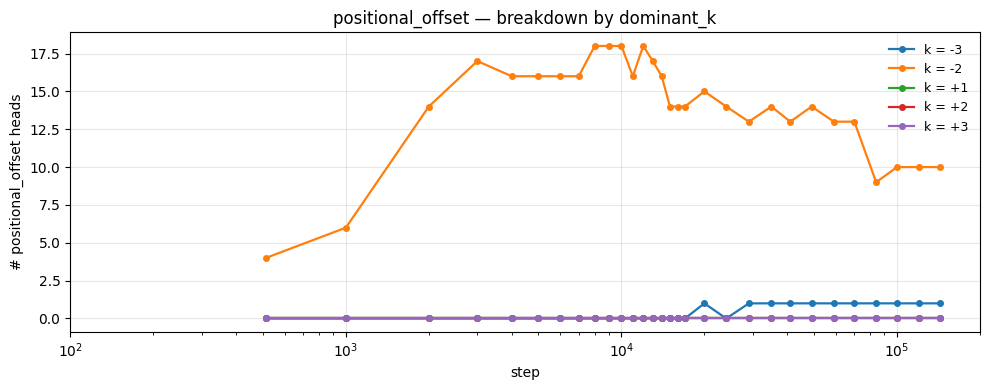

saved notebooks/figures/atlas_v1/F5_positional_offset_dominant_k.png


In [6]:
po = atlas[atlas["motif"] == "positional_offset"].copy()
po = po[po["score"] >= 0.15]
k_breakdown = po.groupby(["step", "dominant_k"]).size().unstack(fill_value=0).sort_index()
k_breakdown = k_breakdown.reindex(columns=[-3, -2, 1, 2, 3], fill_value=0)

print("positional_offset dominant_k counts (heads passing 0.15) across training:\n")
print(k_breakdown.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for k in [-3, -2, 1, 2, 3]:
    if k in k_breakdown.columns:
        ax.plot(
            k_breakdown.index.values + 1,
            k_breakdown[k].values,
            "o-",
            linewidth=1.6,
            markersize=4,
            label=f"k = {k:+d}",
        )
ax.set_xscale("log")
ax.set_xlim(100, 200_000)
ax.set_xlabel("step")
ax.set_ylabel("# positional_offset heads")
ax.set_title("positional_offset — breakdown by dominant_k")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "F5_positional_offset_dominant_k.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'F5_positional_offset_dominant_k.png').relative_to(REPO)}")


## §6. Cross-family head overlap at convergence (step 143000)

How often does a single head pass *multiple* family thresholds at the final checkpoint?
8×8 matrix where M[i, j] = number of heads passing both family i and family j.
Diagonal = single-family pass count.


Cross-family overlap @ step 143000 (heads passing BOTH families):
                   induction  successor  s_inhibition  previous_token  \
induction                 19          0             0               0   
successor                  0          2             0               0   
s_inhibition               0          0             2               0   
previous_token             0          0             0              34   
duplicate_token            0          0             0               0   
positional_offset          0          0             0               9   
bos_attention              6          1             2               1   
delimiter                  0          0             0               8   

                   duplicate_token  positional_offset  bos_attention  \
induction                        0                  0              6   
successor                        0                  0              1   
s_inhibition                     0                  0       

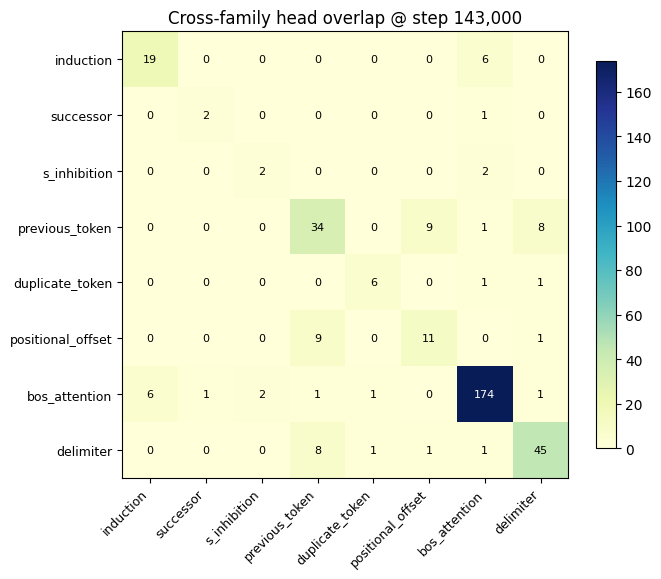


saved notebooks/figures/atlas_v1/F6_cross_family_overlap.png


In [7]:
final_step = 143000
final = combined[combined["step"] == final_step].copy()

# Build pass-flag table: index = (layer, head), columns = motif, values = bool
final["passes"] = False
for motif in MOTIF_ORDER:
    thr_val, op = THRESHOLDS[motif]
    mask = final["motif"] == motif
    if op == "gt":
        final.loc[mask, "passes"] = final.loc[mask, "score"] > thr_val
    else:
        final.loc[mask, "passes"] = final.loc[mask, "score"] >= thr_val

pass_pivot = final.pivot_table(
    index=["layer", "head"], columns="motif", values="passes", fill_value=False, aggfunc="first"
).astype(bool)
pass_pivot = pass_pivot.reindex(columns=MOTIF_ORDER, fill_value=False)

# Cross-family overlap counts
n = len(MOTIF_ORDER)
overlap = np.zeros((n, n), dtype=int)
for i, mi in enumerate(MOTIF_ORDER):
    for j, mj in enumerate(MOTIF_ORDER):
        overlap[i, j] = int((pass_pivot[mi] & pass_pivot[mj]).sum())

overlap_df = pd.DataFrame(overlap, index=MOTIF_ORDER, columns=MOTIF_ORDER)
print("Cross-family overlap @ step 143000 (heads passing BOTH families):")
print(overlap_df)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(overlap, cmap="YlGnBu")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(MOTIF_ORDER, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(MOTIF_ORDER, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(overlap[i, j]), ha="center", va="center", fontsize=8,
                color="white" if overlap[i, j] > overlap.max() * 0.5 else "black")
ax.set_title(f"Cross-family head overlap @ step {final_step:,}")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "F6_cross_family_overlap.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"\nsaved {(FIG_DIR / 'F6_cross_family_overlap.png').relative_to(REPO)}")


## §7. Family-membership typology — multi-family heads

For each (layer, head), count how many families it belongs to at convergence. Lists the
top heads by multi-family membership — heads that fire across multiple detectors are
candidates for further mech-interp investigation (could be genuinely polysemantic, or
could indicate threshold overlap).


In [8]:
membership_count = pass_pivot.sum(axis=1)
multi = pass_pivot[membership_count >= 2].copy()
multi["n_families"] = membership_count[membership_count >= 2]

# Top heads by membership count
multi_sorted = multi.sort_values("n_families", ascending=False)
print(f"heads passing ≥2 families at step {final_step:,}: {len(multi)}")
print(f"heads passing ≥3 families: {(membership_count >= 3).sum()}")
print(f"heads passing ≥4 families: {(membership_count >= 4).sum()}")
print()
print("Top-20 multi-family heads:")
display_cols = ["n_families"] + MOTIF_ORDER
print(multi_sorted[display_cols].head(20).to_string())


heads passing ≥2 families at step 143,000: 29
heads passing ≥3 families: 1
heads passing ≥4 families: 0

Top-20 multi-family heads:
motif       n_families  induction  successor  s_inhibition  previous_token  duplicate_token  positional_offset  bos_attention  delimiter
layer head                                                                                                                              
3     1              3      False      False         False            True            False               True          False       True
0     9              2      False      False         False            True            False               True          False      False
7     7              2       True      False         False           False            False              False           True      False
21    2              2      False      False         False            True            False              False           True      False
19    15             2      False      False  

## §8. Score distributions per family at convergence

Histogram per family at step 143000. Useful for sanity-checking the threshold choices and
spotting families where the score distribution is bimodal (clean separation) vs unimodal
(noisy / arbitrary threshold).


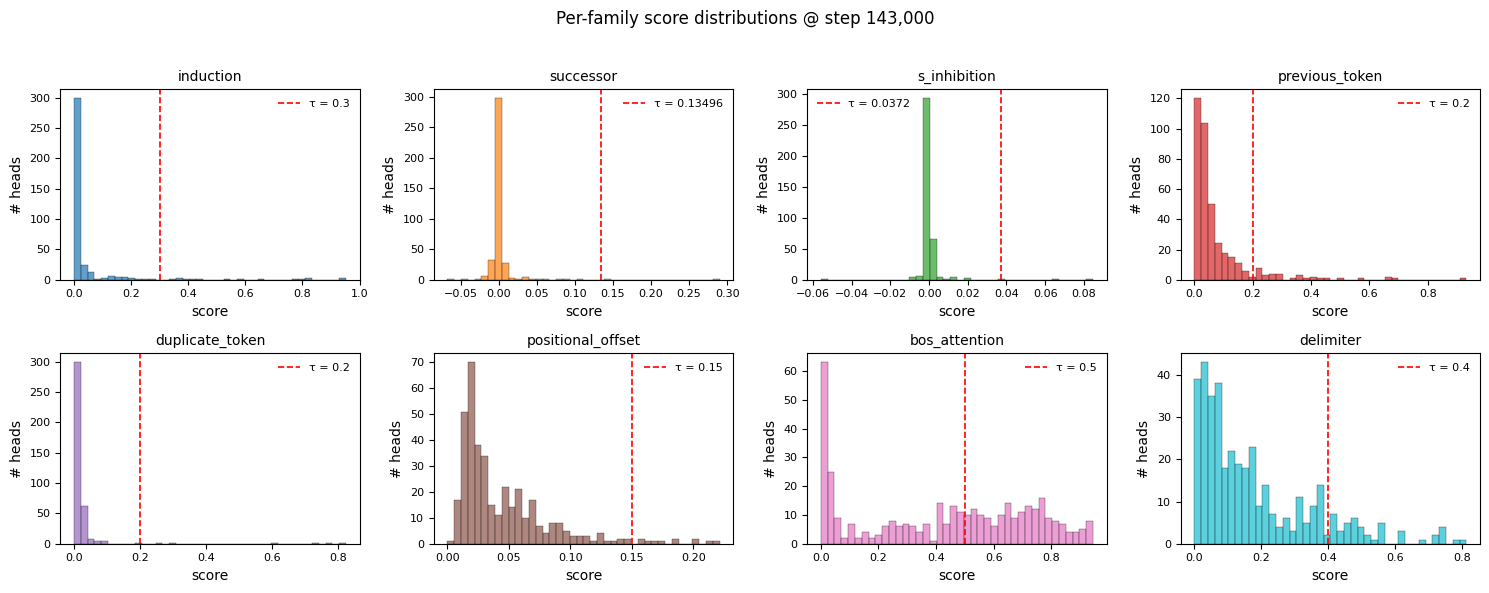

saved notebooks/figures/atlas_v1/F7_score_distributions.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, motif in zip(axes.flatten(), MOTIF_ORDER):
    thr_val, _ = THRESHOLDS[motif]
    sub = combined[(combined["step"] == final_step) & (combined["motif"] == motif)]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    ax.hist(sub["score"].values, bins=40, color=MOTIF_COLORS[motif], alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.axvline(thr_val, color="red", linestyle="--", linewidth=1.2, label=f"τ = {thr_val}")
    ax.set_title(motif, fontsize=10)
    ax.set_xlabel("score")
    ax.set_ylabel("# heads")
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, frameon=False)
fig.suptitle(f"Per-family score distributions @ step {final_step:,}", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig(FIG_DIR / "F7_score_distributions.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR / 'F7_score_distributions.png').relative_to(REPO)}")


## Summary

Atlas-v1 maps 8 attention-head families at Pythia-410M across 40 §H2-1 checkpoints. Three
patterns stand out:

1. **Transient over-emergence in delimiter**: ~211 heads pass at step 12000, only ~45
   retain the role at convergence. Stepping-stone hypothesis.
2. **BOS-attention is the dominant late-emerging family**: 174 heads pass at convergence;
   the count is still growing at step 120000. Consistent with "BOS sink" (Anthropic 2021).
3. **Positional-offset is dominated by k = -2** (skip-1 attention), not the more common
   k = +1 or k = -3 / +3.

Cross-family overlap analysis surfaces multi-functional heads worth deeper mech-interp
investigation. Score-distribution histograms confirm the per-family threshold calibration
is sensible — most families show clean bimodal distributions with the threshold cleanly
separating the modes.

**Next steps:**
- Multi-seed sweep (currently single seed=0) to quantify trajectory variance.
- Extend to other Pythia sizes (70m, 160m, 1b, 2.8b) for emergence-vs-scale comparison.
- Drill into individual heads with deeper diagnostics (which inputs activate them?).
